# 05 Combined Polling Panel and Cologne Extension

This notebook builds a combined monthly polling series by concatenating:
- historical manual Wahlrecht supplement (2013-09 to 2016-12), and
- DAWUM monthly series (2017-01 to 2025-12),

then merges the combined polling series with the monthly media salience indicator.

Scope is descriptive only (no causal claims, no event-study regression).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
POLLING_MANUAL_DIR = DATA_DIR / 'polling' / 'manual'
POLLING_PROCESSED_DIR = DATA_DIR / 'polling' / 'processed'
INDICATORS_DIR = DATA_DIR / 'indicators'
PANEL_DIR = DATA_DIR / 'panel'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '05_notebook_figures'

for d in [POLLING_PROCESSED_DIR, PANEL_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

HIST_PARQUET = POLLING_MANUAL_DIR / 'afd_polling_historical_manual_monthly.parquet'
HIST_CSV = POLLING_MANUAL_DIR / 'afd_polling_historical_manual_monthly.csv'
DAWUM_PARQUET = POLLING_PROCESSED_DIR / 'afd_polling_monthly_2017_2025.parquet'
DAWUM_CSV = POLLING_PROCESSED_DIR / 'afd_polling_monthly_2017_2025.csv'
MEDIA_PARQUET = INDICATORS_DIR / 'monthly_media_salience_indicator.parquet'
MEDIA_CSV = INDICATORS_DIR / 'monthly_media_salience_indicator.csv'

OUT_COMBINED_POLLING_CSV = POLLING_PROCESSED_DIR / 'afd_polling_monthly_combined_2013_2025.csv'
OUT_COMBINED_POLLING_PARQUET = POLLING_PROCESSED_DIR / 'afd_polling_monthly_combined_2013_2025.parquet'

OUT_COMBINED_PANEL_CSV = PANEL_DIR / 'monthly_salience_polling_panel_combined_2013_2025.csv'
OUT_COMBINED_PANEL_PARQUET = PANEL_DIR / 'monthly_salience_polling_panel_combined_2013_2025.parquet'
OUT_EVENT_SUMMARY_CSV = PANEL_DIR / 'event_window_descriptive_summary_combined_2013_2025.csv'

ANALYSIS_START = pd.Timestamp('2013-09-01')
ANALYSIS_END = pd.Timestamp('2025-12-31')
EXPECTED_MONTHS = pd.period_range(ANALYSIS_START, ANALYSIS_END, freq='M')
EXPECTED_ROWS = len(EXPECTED_MONTHS)

COLOGNE_MONTH = pd.Timestamp('2016-01-01')
CHEMNITZ_MONTH = pd.Timestamp('2018-08-01')
CORRECTIV_MONTH = pd.Timestamp('2024-01-01')
DAWUM_BEGIN_MONTH = pd.Timestamp('2017-01-01')

print('PROJECT_ROOT:', PROJECT_ROOT)
print('EXPECTED_ROWS:', EXPECTED_ROWS)
print('ANALYSIS WINDOW:', ANALYSIS_START.date(), 'to', ANALYSIS_END.date())

PROJECT_ROOT: c:\PythonProjects\AfD-project
EXPECTED_ROWS: 148
ANALYSIS WINDOW: 2013-09-01 to 2025-12-31


In [2]:
def load_table(parquet_path: Path, csv_path: Path) -> pd.DataFrame:
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'Missing both parquet and csv: {parquet_path} | {csv_path}')

historical = load_table(HIST_PARQUET, HIST_CSV)
dawum = load_table(DAWUM_PARQUET, DAWUM_CSV)
media = load_table(MEDIA_PARQUET, MEDIA_CSV)

print('historical shape:', historical.shape)
print('dawum shape:', dawum.shape)
print('media shape:', media.shape)
print('historical columns:', list(historical.columns))
print('dawum columns:', list(dawum.columns))
print('media columns:', list(media.columns))
print('historical head:')
print(historical.head(3))
print('dawum head:')
print(dawum.head(3))

historical shape: (40, 17)
dawum shape: (108, 15)
media shape: (156, 17)
historical columns: ['month', 'year_month', 'month_dt', 'year', 'month_num', 'afd_poll_support_mean', 'afd_poll_support_median', 'afd_poll_support_min', 'afd_poll_support_max', 'afd_poll_support_sd', 'n_polls', 'n_pollsters', 'first_poll_date', 'last_poll_date', 'source', 'collection_method', 'notes']
dawum columns: ['month', 'year_month', 'month_dt', 'year', 'month_num', 'afd_poll_support_mean', 'afd_poll_support_median', 'afd_poll_support_min', 'afd_poll_support_max', 'afd_poll_support_sd', 'n_polls', 'n_pollsters', 'first_poll_date', 'last_poll_date', 'source']
media columns: ['month', 'year_month', 'year', 'month_num', 'nexis_total_results', 'media_salience_volume_raw', 'media_salience_volume_log1p', 'media_salience_volume_z', 'raw_article_count', 'download_fraction', 'retrieval_mismatch_flag', 'high_download_sample_flag', 'kept_article_count', 'cleaned_sample_size', 'cleaned_sample_fraction', 'cleaned_sample_

In [3]:
def standardize_polling_schema(df: pd.DataFrame, block: str) -> pd.DataFrame:
    out = df.copy()

    if 'month_dt' in out.columns:
        out['month_dt'] = pd.to_datetime(out['month_dt'], errors='coerce')
    elif 'year_month' in out.columns:
        out['month_dt'] = pd.to_datetime(out['year_month'].astype(str).str[:7] + '-01', errors='coerce')
    elif 'month' in out.columns:
        out['month_dt'] = pd.to_datetime(out['month'].astype(str).str[:7] + '-01', errors='coerce')
    else:
        raise ValueError('Polling frame missing month_dt/year_month/month')

    if out['month_dt'].isna().any():
        raise ValueError(f'{block}: month_dt parse failed for some rows')

    out['year_month'] = out['month_dt'].dt.strftime('%Y-%m')
    out['month'] = out['year_month']
    out['year'] = out['month_dt'].dt.year
    out['month_num'] = out['month_dt'].dt.month

    num_cols = ['afd_poll_support_mean', 'afd_poll_support_median', 'afd_poll_support_sd', 'n_polls', 'n_pollsters']
    for c in num_cols:
        if c not in out.columns:
            out[c] = np.nan
        out[c] = pd.to_numeric(out[c], errors='coerce')

    for c in ['first_poll_date', 'last_poll_date']:
        if c not in out.columns:
            out[c] = pd.NaT
        out[c] = pd.to_datetime(out[c], errors='coerce')

    if 'source' not in out.columns:
        out['source'] = 'DAWUM' if block == 'dawum' else 'Wahlrecht.de'

    if 'collection_method' not in out.columns:
        out['collection_method'] = 'dawum_api_processed_monthly' if block == 'dawum' else 'manual_wahlrecht_historical_supplement'

    if 'notes' not in out.columns:
        out['notes'] = 'DAWUM monthly Bundestag AfD polling series' if block == 'dawum' else 'Pre-DAWUM historical supplement for Cologne-period descriptive diagnostics.'

    out['polling_source_block'] = 'dawum' if block == 'dawum' else 'historical_manual_wahlrecht'

    required = [
        'month', 'year_month', 'month_dt', 'year', 'month_num',
        'afd_poll_support_mean', 'afd_poll_support_median', 'afd_poll_support_sd',
        'n_polls', 'n_pollsters', 'first_poll_date', 'last_poll_date',
        'polling_source_block', 'source', 'collection_method', 'notes'
    ]

    for c in required:
        if c not in out.columns:
            out[c] = np.nan

    out = out.sort_values('month_dt').reset_index(drop=True)
    return out[required + [c for c in out.columns if c not in required]]

hist_std = standardize_polling_schema(historical, 'historical')
dawum_std = standardize_polling_schema(dawum, 'dawum')

print('hist_std shape:', hist_std.shape)
print('dawum_std shape:', dawum_std.shape)
print(hist_std[['year_month','afd_poll_support_mean','polling_source_block','source']].head(2))
print(dawum_std[['year_month','afd_poll_support_mean','polling_source_block','source']].head(2))

hist_std shape: (40, 18)
dawum_std shape: (108, 18)
  year_month  afd_poll_support_mean         polling_source_block        source
0    2013-09                  4.775  historical_manual_wahlrecht  Wahlrecht.de
1    2013-10                  5.125  historical_manual_wahlrecht  Wahlrecht.de
  year_month  afd_poll_support_mean polling_source_block source
0    2017-01              12.186667                dawum  DAWUM
1    2017-02              10.356522                dawum  DAWUM


In [4]:
def zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - mu) / sd

# Validate ranges
hist_months = pd.PeriodIndex(hist_std['month_dt'].dt.to_period('M').unique(), freq='M')
dawum_months = pd.PeriodIndex(dawum_std['month_dt'].dt.to_period('M').unique(), freq='M')

if hist_months.min() != pd.Period('2013-09', freq='M') or hist_months.max() != pd.Period('2016-12', freq='M'):
    raise ValueError(f'Historical range mismatch: {hist_months.min()} to {hist_months.max()}')
if dawum_months.min() != pd.Period('2017-01', freq='M') or dawum_months.max() != pd.Period('2025-12', freq='M'):
    raise ValueError(f'DAWUM range mismatch: {dawum_months.min()} to {dawum_months.max()}')

if len(hist_std['year_month']) != hist_std['year_month'].nunique():
    raise ValueError('Historical contains duplicate months.')
if len(dawum_std['year_month']) != dawum_std['year_month'].nunique():
    raise ValueError('DAWUM contains duplicate months.')

overlap = sorted(set(hist_std['year_month']).intersection(set(dawum_std['year_month'])))
if overlap:
    raise ValueError(f'Historical and DAWUM overlap months: {overlap[:10]}')

for name,df in [('historical',hist_std),('dawum',dawum_std)]:
    if df['afd_poll_support_mean'].isna().any():
        raise ValueError(f'{name}: missing afd_poll_support_mean values')
    for c in ['afd_poll_support_mean','afd_poll_support_median','n_polls']:
        if not pd.api.types.is_numeric_dtype(df[c]):
            raise ValueError(f'{name}: non-numeric column {c}')

combined_polling = pd.concat([hist_std, dawum_std], ignore_index=True)
combined_polling = combined_polling.sort_values('month_dt').reset_index(drop=True)
combined_polling['year_month'] = combined_polling['month_dt'].dt.strftime('%Y-%m')
combined_polling['month'] = combined_polling['year_month']
combined_polling['year'] = combined_polling['month_dt'].dt.year
combined_polling['month_num'] = combined_polling['month_dt'].dt.month

if len(combined_polling['year_month']) != combined_polling['year_month'].nunique():
    raise ValueError('Combined polling has duplicate months.')

actual_months = pd.PeriodIndex(combined_polling['month_dt'].dt.to_period('M').unique(), freq='M')
missing_months = EXPECTED_MONTHS.difference(actual_months)
if len(combined_polling) != EXPECTED_ROWS or len(missing_months) > 0:
    raise ValueError(
        f'Combined polling coverage mismatch: rows={len(combined_polling)} expected={EXPECTED_ROWS}; '
        f'missing={ [m.strftime("%Y-%m") for m in missing_months] }'
    )

combined_polling['afd_poll_support_z_combined'] = zscore(combined_polling['afd_poll_support_mean'])

combined_polling.to_csv(OUT_COMBINED_POLLING_CSV, index=False)
combined_polling.to_parquet(OUT_COMBINED_POLLING_PARQUET, index=False)

print('Saved combined polling CSV:', OUT_COMBINED_POLLING_CSV)
print('Saved combined polling parquet:', OUT_COMBINED_POLLING_PARQUET)
print('combined_polling rows:', len(combined_polling))
print('combined polling coverage:', combined_polling['month_dt'].min(), 'to', combined_polling['month_dt'].max())
print('source block counts:')
print(combined_polling['polling_source_block'].value_counts())
print('AfD support summary by source block:')
print(combined_polling.groupby('polling_source_block')['afd_poll_support_mean'].describe())
print('n_polls summary by source block:')
print(combined_polling.groupby('polling_source_block')['n_polls'].describe())

Saved combined polling CSV: c:\PythonProjects\AfD-project\data\polling\processed\afd_polling_monthly_combined_2013_2025.csv
Saved combined polling parquet: c:\PythonProjects\AfD-project\data\polling\processed\afd_polling_monthly_combined_2013_2025.parquet
combined_polling rows: 148
combined polling coverage: 2013-09-01 00:00:00 to 2025-12-01 00:00:00
source block counts:
polling_source_block
dawum                          108
historical_manual_wahlrecht     40
Name: count, dtype: int64
AfD support summary by source block:
                             count       mean       std       min        25%        50%        75%        max
polling_source_block                                                                                         
dawum                        108.0  14.641958  4.732661  7.896000  10.723103  13.745238  17.511364  26.022727
historical_manual_wahlrecht   40.0   7.609167  3.501227  3.333333   4.750000   6.100000  10.850000  14.333333
n_polls summary by source block:

In [5]:
# Media standardization and merge
media_std = media.copy()
if 'month_dt' in media_std.columns:
    media_std['month_dt'] = pd.to_datetime(media_std['month_dt'], errors='coerce')
elif 'year_month' in media_std.columns:
    media_std['month_dt'] = pd.to_datetime(media_std['year_month'].astype(str).str[:7] + '-01', errors='coerce')
else:
    media_std['month_dt'] = pd.to_datetime(media_std['month'].astype(str).str[:7] + '-01', errors='coerce')

media_std['year_month'] = media_std['month_dt'].dt.strftime('%Y-%m')
media_std['month'] = media_std['year_month']
media_std['year'] = media_std['month_dt'].dt.year
media_std['month_num'] = media_std['month_dt'].dt.month

media_window = media_std[(media_std['month_dt'] >= ANALYSIS_START) & (media_std['month_dt'] <= ANALYSIS_END)].copy()
media_window = media_window.sort_values('month_dt').reset_index(drop=True)

if len(media_window['year_month']) != media_window['year_month'].nunique():
    raise ValueError('Media window has duplicate months.')

panel = combined_polling.merge(
    media_window,
    on='year_month',
    how='inner',
    suffixes=('_polling', '_media'),
    validate='one_to_one',
)

panel['month_dt'] = pd.to_datetime(panel['month_dt_polling'], errors='coerce')
panel['month'] = panel['year_month']
panel['year'] = panel['month_dt'].dt.year
panel['month_num'] = panel['month_dt'].dt.month

if len(panel) != EXPECTED_ROWS:
    raise ValueError(f'Combined panel rows mismatch: {len(panel)} vs expected {EXPECTED_ROWS}')
if panel['year_month'].duplicated().any():
    raise ValueError('Combined panel has duplicate months.')
if panel['afd_poll_support_mean'].isna().any():
    raise ValueError('Combined panel has missing afd_poll_support_mean.')
if panel['nexis_total_results'].isna().any():
    raise ValueError('Combined panel has missing nexis_total_results.')
if 'retrieval_mismatch_flag' in panel.columns:
    mismatch_count = int(panel['retrieval_mismatch_flag'].fillna(False).astype(bool).sum())
    if mismatch_count != 0:
        raise ValueError(f'Combined panel retrieval_mismatch_flag true count: {mismatch_count}')

# Keep global z and add within-panel z for salience
panel['media_salience_volume_z_panel'] = zscore(panel['nexis_total_results'])
if 'afd_poll_support_z_combined' not in panel.columns:
    panel['afd_poll_support_z_combined'] = zscore(panel['afd_poll_support_mean'])

panel = panel.sort_values('month_dt').reset_index(drop=True)

preferred_front = [
    'month', 'year_month', 'month_dt', 'year', 'month_num',
    'polling_source_block', 'source_polling', 'collection_method', 'notes',
    'afd_poll_support_mean', 'afd_poll_support_median', 'afd_poll_support_sd',
    'n_polls', 'n_pollsters', 'first_poll_date', 'last_poll_date',
    'afd_poll_support_z_combined',
    'nexis_total_results', 'media_salience_volume_raw', 'media_salience_volume_log1p',
    'media_salience_volume_z', 'media_salience_volume_z_panel',
    'raw_article_count', 'download_fraction', 'kept_article_count', 'cleaned_sample_size',
    'cleaned_sample_fraction', 'retrieval_mismatch_flag', 'high_download_sample_flag'
]
existing_front = [c for c in preferred_front if c in panel.columns]
other_cols = [c for c in panel.columns if c not in existing_front]
panel_out = panel[existing_front + other_cols].copy()

panel_out.to_csv(OUT_COMBINED_PANEL_CSV, index=False)
panel_out.to_parquet(OUT_COMBINED_PANEL_PARQUET, index=False)

print('Saved combined panel CSV:', OUT_COMBINED_PANEL_CSV)
print('Saved combined panel parquet:', OUT_COMBINED_PANEL_PARQUET)
print('combined panel rows:', len(panel_out))
print('combined panel coverage:', panel_out['month_dt'].min(), 'to', panel_out['month_dt'].max())

Saved combined panel CSV: c:\PythonProjects\AfD-project\data\panel\monthly_salience_polling_panel_combined_2013_2025.csv
Saved combined panel parquet: c:\PythonProjects\AfD-project\data\panel\monthly_salience_polling_panel_combined_2013_2025.parquet
combined panel rows: 148
combined panel coverage: 2013-09-01 00:00:00 to 2025-12-01 00:00:00


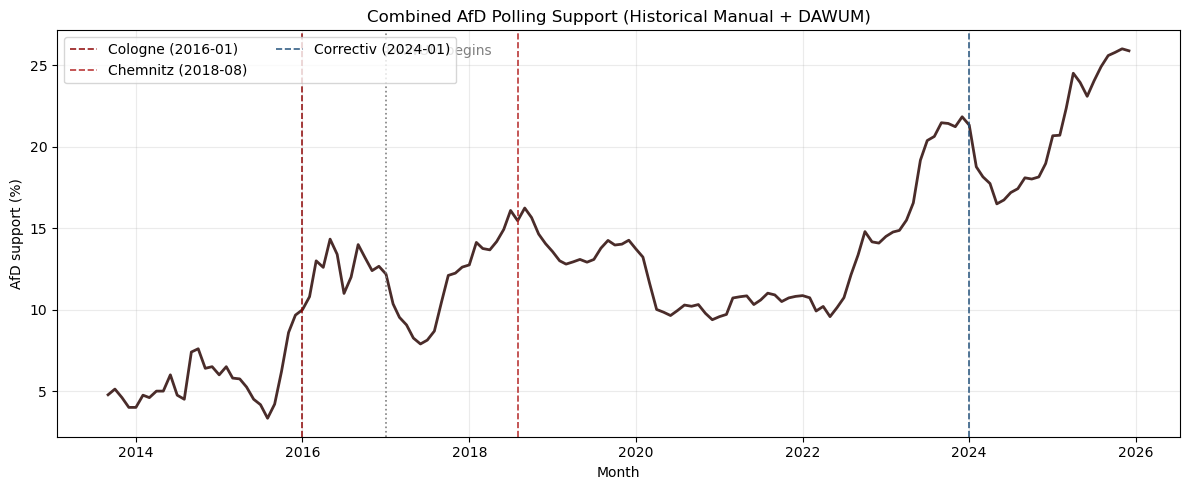

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\afd_polling_combined_monthly.png


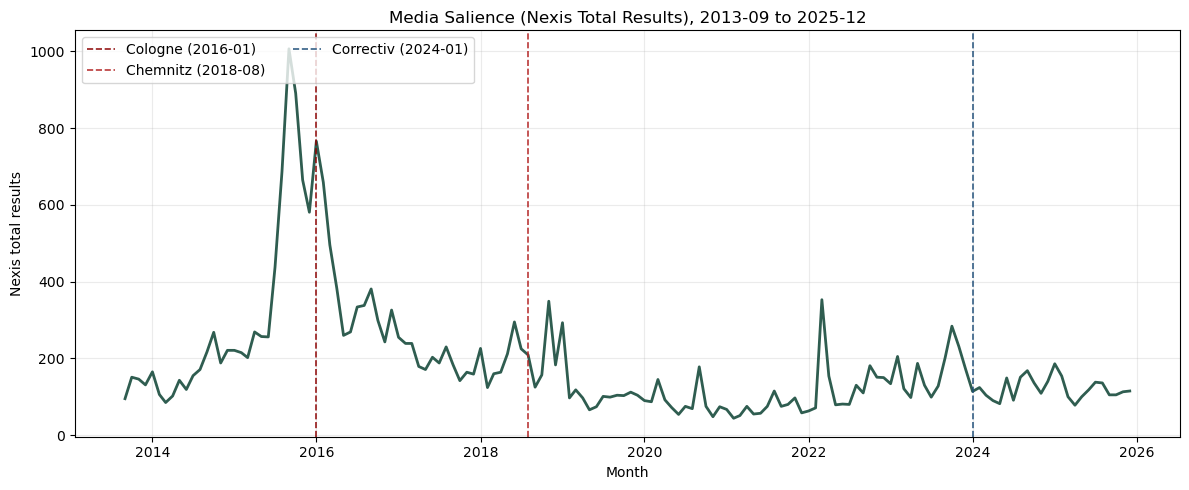

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\media_salience_combined_panel.png


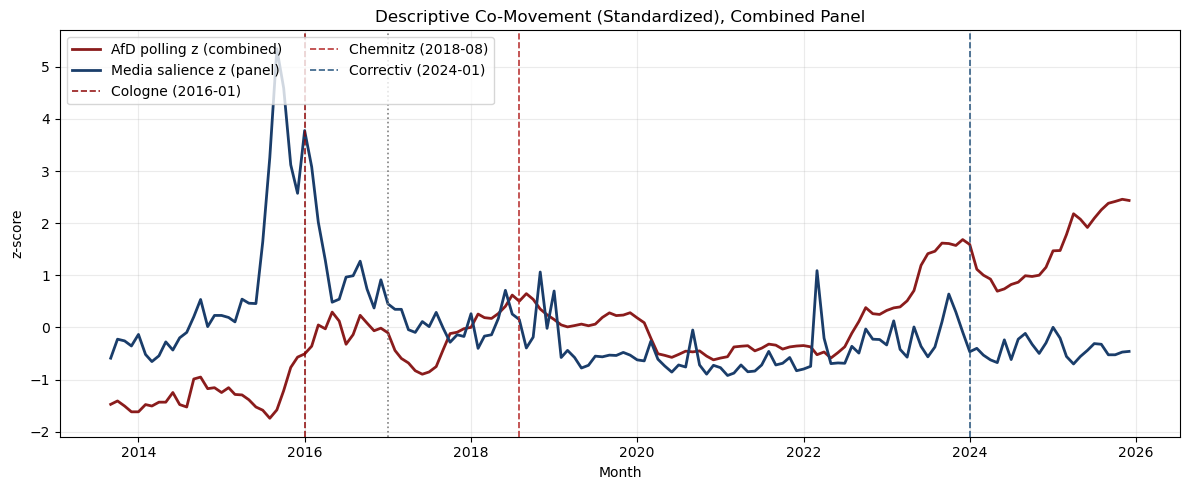

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\combined_standardized_comovement.png


In [6]:
def add_shock_lines(ax):
    ax.axvline(COLOGNE_MONTH, color='#8b0000', linestyle='--', linewidth=1.2, alpha=0.9, label='Cologne (2016-01)')
    ax.axvline(CHEMNITZ_MONTH, color='#b22222', linestyle='--', linewidth=1.2, alpha=0.9, label='Chemnitz (2018-08)')
    ax.axvline(CORRECTIV_MONTH, color='#1f4e79', linestyle='--', linewidth=1.2, alpha=0.9, label='Correctiv (2024-01)')

# a) Combined polling support
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(panel_out['month_dt'], panel_out['afd_poll_support_mean'], color='#4a2c2a', linewidth=2)
add_shock_lines(ax)
ax.axvline(DAWUM_BEGIN_MONTH, color='gray', linestyle=':', linewidth=1.2)
ax.text(DAWUM_BEGIN_MONTH, ax.get_ylim()[1]*0.97, 'DAWUM begins', color='gray', ha='left', va='top')
ax.set_title('Combined AfD Polling Support (Historical Manual + DAWUM)')
ax.set_xlabel('Month')
ax.set_ylabel('AfD support (%)')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', ncol=2)
fig.tight_layout()
out1 = FIGURES_DIR / 'afd_polling_combined_monthly.png'
fig.savefig(out1, dpi=150)
plt.show()
print('Saved:', out1)

# b) Media salience in combined window
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(panel_out['month_dt'], panel_out['nexis_total_results'], color='#2f5d50', linewidth=2)
add_shock_lines(ax)
ax.set_title('Media Salience (Nexis Total Results), 2013-09 to 2025-12')
ax.set_xlabel('Month')
ax.set_ylabel('Nexis total results')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', ncol=2)
fig.tight_layout()
out2 = FIGURES_DIR / 'media_salience_combined_panel.png'
fig.savefig(out2, dpi=150)
plt.show()
print('Saved:', out2)

# c) Standardized co-movement
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(panel_out['month_dt'], panel_out['afd_poll_support_z_combined'], color='#8a1c1c', linewidth=2, label='AfD polling z (combined)')
ax.plot(panel_out['month_dt'], panel_out['media_salience_volume_z_panel'], color='#1a3d6a', linewidth=2, label='Media salience z (panel)')
add_shock_lines(ax)
ax.axvline(DAWUM_BEGIN_MONTH, color='gray', linestyle=':', linewidth=1.2)
ax.set_title('Descriptive Co-Movement (Standardized), Combined Panel')
ax.set_xlabel('Month')
ax.set_ylabel('z-score')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', ncol=2)
fig.tight_layout()
out3 = FIGURES_DIR / 'combined_standardized_comovement.png'
fig.savefig(out3, dpi=150)
plt.show()
print('Saved:', out3)

In [7]:
def extract_event_window(df: pd.DataFrame, shock_month: pd.Timestamp, pre_months: int = 6, post_months: int = 6) -> pd.DataFrame:
    start = shock_month - pd.DateOffset(months=pre_months)
    end = shock_month + pd.DateOffset(months=post_months)
    w = df[(df['month_dt'] >= start) & (df['month_dt'] <= end)].copy()
    w['rel_month'] = ((w['month_dt'].dt.year - shock_month.year) * 12 + (w['month_dt'].dt.month - shock_month.month)).astype(int)
    w = w.sort_values('month_dt').reset_index(drop=True)
    return w


def pre_post_summary(w: pd.DataFrame, label: str, shock_month: pd.Timestamp, pre_m: int, post_m: int) -> dict:
    pre = w[w['rel_month'] < 0]
    post = w[w['rel_month'] > 0]
    shock = w[w['rel_month'] == 0]

    afd_shock = float(shock['afd_poll_support_mean'].iloc[0]) if len(shock) == 1 else np.nan
    salience_shock = float(shock['media_salience_volume_z_panel'].iloc[0]) if len(shock) == 1 else np.nan

    return {
        'shock_label': label,
        'shock_month': shock_month.strftime('%Y-%m'),
        'pre_months': pre_m,
        'post_months': post_m,
        'afd_pre_mean': pre['afd_poll_support_mean'].mean(),
        'afd_post_mean': post['afd_poll_support_mean'].mean(),
        'afd_change_post_minus_pre': post['afd_poll_support_mean'].mean() - pre['afd_poll_support_mean'].mean(),
        'salience_pre_mean': pre['media_salience_volume_z_panel'].mean(),
        'salience_post_mean': post['media_salience_volume_z_panel'].mean(),
        'salience_change_post_minus_pre': post['media_salience_volume_z_panel'].mean() - pre['media_salience_volume_z_panel'].mean(),
        'afd_shock_month': afd_shock,
        'salience_shock_month': salience_shock,
        'n_months_pre': int(len(pre)),
        'n_months_post': int(len(post)),
    }

shocks = [
    ('Cologne', COLOGNE_MONTH),
    ('Chemnitz', CHEMNITZ_MONTH),
    ('Correctiv', CORRECTIV_MONTH),
]

summary_rows = []
for label, sm in shocks:
    for win in [3, 6]:
        w = extract_event_window(panel_out, sm, pre_months=win, post_months=win)
        summary_rows.append(pre_post_summary(w, label, sm, win, win))

event_summary = pd.DataFrame(summary_rows).sort_values(['shock_month','pre_months']).reset_index(drop=True)
event_summary.to_csv(OUT_EVENT_SUMMARY_CSV, index=False)
print('Saved event summary:', OUT_EVENT_SUMMARY_CSV)
print(event_summary)

Saved event summary: c:\PythonProjects\AfD-project\data\panel\event_window_descriptive_summary_combined_2013_2025.csv
  shock_label shock_month  pre_months  post_months  afd_pre_mean  afd_post_mean  afd_change_post_minus_pre  salience_pre_mean  salience_post_mean  salience_change_post_minus_pre  \
0     Cologne     2016-01           3            3      8.155556      12.133333                   3.977778           3.427984            2.128649                       -1.299335   
1     Cologne     2016-01           6            6      6.027778      12.522222                   6.494444           3.422561            1.396552                       -2.026009   
2    Chemnitz     2018-08           3            3     15.070079      15.515632                   0.445552           0.380294            0.161208                       -0.219087   
3    Chemnitz     2018-08           6            6     14.462367      14.529741                   0.067374           0.072272            0.098302             

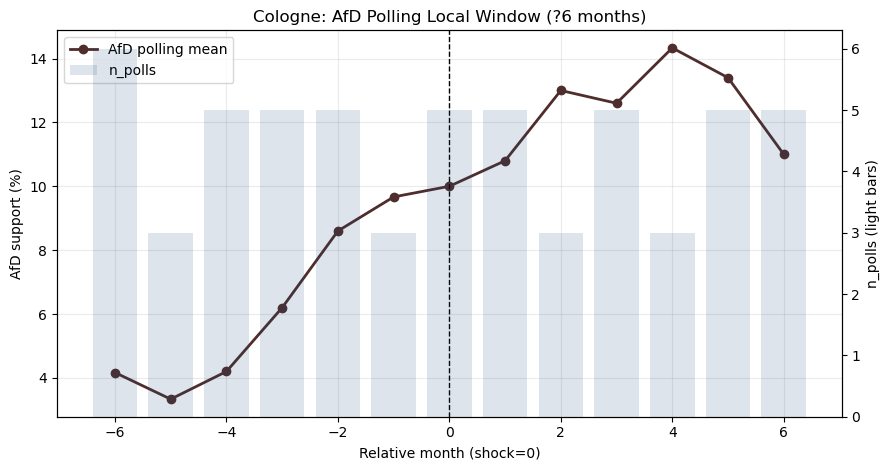

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\cologne_afd_polling_event_window.png


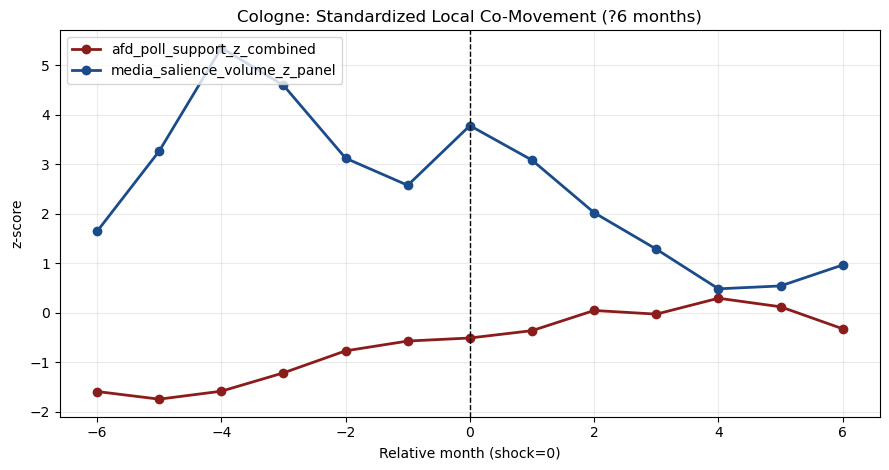

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\cologne_comovement_event_window.png


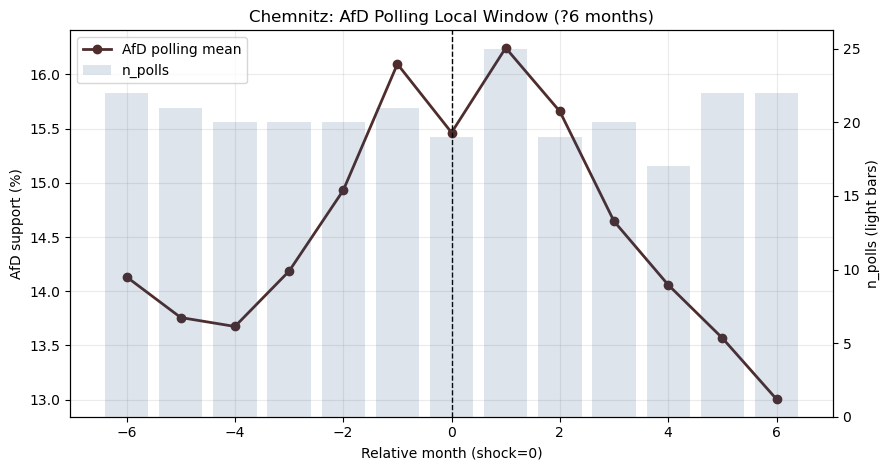

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\chemnitz_afd_polling_event_window.png


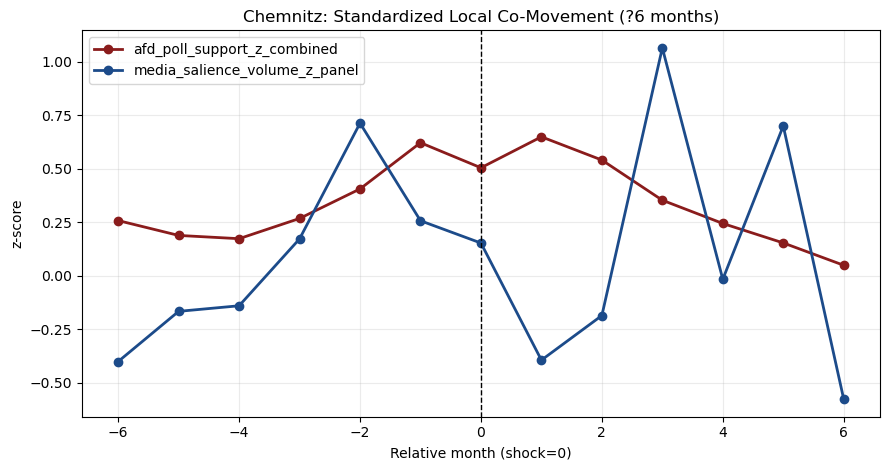

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\chemnitz_comovement_event_window.png


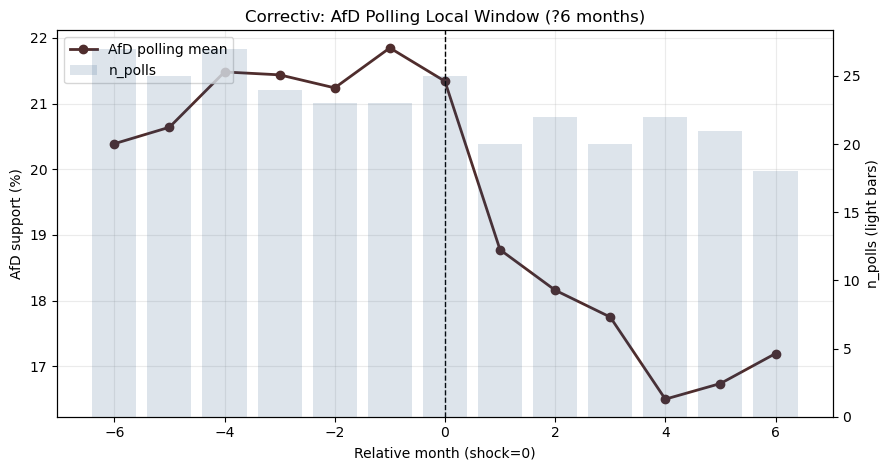

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\correctiv_afd_polling_event_window.png


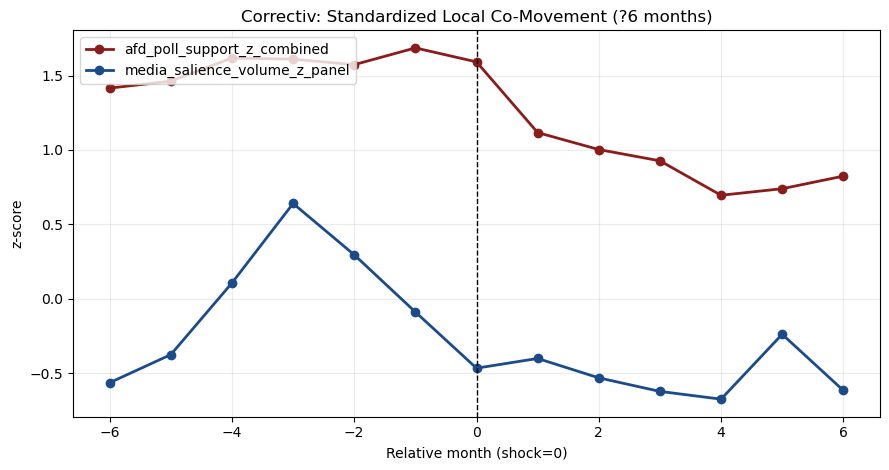

Saved: c:\PythonProjects\AfD-project\figures\05_notebook_figures\correctiv_comovement_event_window.png


In [8]:
def plot_event_windows(df: pd.DataFrame, label: str, shock_month: pd.Timestamp):
    w = extract_event_window(df, shock_month, pre_months=6, post_months=6)
    slug = label.lower()

    # Polling local window
    fig, ax1 = plt.subplots(figsize=(9, 4.8))
    ax1.plot(w['rel_month'], w['afd_poll_support_mean'], marker='o', linewidth=2, color='#4f2d2d', label='AfD polling mean')
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.set_title(f'{label}: AfD Polling Local Window (?6 months)')
    ax1.set_xlabel('Relative month (shock=0)')
    ax1.set_ylabel('AfD support (%)')
    ax1.grid(alpha=0.25)
    ax2 = ax1.twinx()
    ax2.bar(w['rel_month'], w['n_polls'], alpha=0.15, color='#1f4e79', width=0.8, label='n_polls')
    ax2.set_ylabel('n_polls (light bars)')
    h1,l1=ax1.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
    ax1.legend(h1+h2,l1+l2,loc='upper left')
    fig.tight_layout()
    f1 = FIGURES_DIR / f'{slug}_afd_polling_event_window.png'
    fig.savefig(f1, dpi=150)
    plt.show()
    print('Saved:', f1)

    # Co-movement local window
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(w['rel_month'], w['afd_poll_support_z_combined'], marker='o', linewidth=2, color='#8a1c1c', label='afd_poll_support_z_combined')
    ax.plot(w['rel_month'], w['media_salience_volume_z_panel'], marker='o', linewidth=2, color='#1c4b8a', label='media_salience_volume_z_panel')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{label}: Standardized Local Co-Movement (?6 months)')
    ax.set_xlabel('Relative month (shock=0)')
    ax.set_ylabel('z-score')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left')
    fig.tight_layout()
    f2 = FIGURES_DIR / f'{slug}_comovement_event_window.png'
    fig.savefig(f2, dpi=150)
    plt.show()
    print('Saved:', f2)

for label, sm in shocks:
    plot_event_windows(panel_out, label, sm)

## Interpretation Notes

- This is a combined descriptive panel.
- Polling for 2013-09 to 2016-12 comes from the manual Wahlrecht.de supplement (Politbarometer, Infratest dimap, GMS).
- Polling for 2017-01 to 2025-12 comes from DAWUM.
- The source boundary (DAWUM begins in 2017-01) should be considered when interpreting long-run trends.
- Cologne is now included descriptively because the historical supplement covers the needed pre/post window.
- Chemnitz and Correctiv remain in the DAWUM section of the panel.
- Results are descriptive and do not establish causal effects.
